In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [52]:
df = pd.read_csv("customer_segmentation_1000.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (1000, 15)


In [53]:
df.head()

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseFrequency,AvgPurchaseAmount,TotalPurchaseValue,OnlinePurchasePercentage,RecencyDays,PreferredCategory,Location,MembershipLevel,DiscountUsagePercentage,SatisfactionScore
0,CUST0001,56,Male,41567,69,5,1021.44,5107.20,15,73,Electronics,Pune,Gold,7,6.6
1,CUST0002,46,Female,58285,50,11,1487.71,16364.81,62,9,Sports,Kolhapur,Silver,31,7.2
2,CUST0003,32,Female,51591,48,5,983.94,4919.70,63,19,Beauty,Aurangabad,Platinum,8,7.0
3,CUST0004,60,Male,60887,43,5,1398.04,6990.20,40,24,Beauty,Mumbai,Basic,41,7.7
4,CUST0005,25,Female,66246,73,15,1226.00,18390.00,37,89,Beauty,Pune,Gold,22,6.4


In [54]:
df.tail()

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseFrequency,AvgPurchaseAmount,TotalPurchaseValue,OnlinePurchasePercentage,RecencyDays,PreferredCategory,Location,MembershipLevel,DiscountUsagePercentage,SatisfactionScore
995,CUST0996,23,Female,104495,90,14,1615.42,22615.88,80,37,Home & Lifestyle,Nashik,Basic,31,6.7
996,CUST0997,43,Male,70062,100,15,1328.86,19932.90,14,9,Grocery,Mumbai,Gold,34,4.7
997,CUST0998,21,Male,75950,51,11,1336.45,14700.95,91,59,Home & Lifestyle,Mumbai,Silver,15,6.5
998,CUST0999,36,Female,79650,64,14,1476.80,20675.20,78,67,Fashion,Mumbai,Silver,40,5.6
999,CUST1000,37,Male,74275,76,12,1347.33,16167.96,57,6,Grocery,Pune,Basic,31,7.6


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                1000 non-null   object 
 1   Age                       1000 non-null   int64  
 2   Gender                    1000 non-null   object 
 3   AnnualIncome              1000 non-null   int64  
 4   SpendingScore             1000 non-null   int64  
 5   PurchaseFrequency         1000 non-null   int64  
 6   AvgPurchaseAmount         1000 non-null   float64
 7   TotalPurchaseValue        1000 non-null   float64
 8   OnlinePurchasePercentage  1000 non-null   int64  
 9   RecencyDays               1000 non-null   int64  
 10  PreferredCategory         1000 non-null   object 
 11  Location                  1000 non-null   object 
 12  MembershipLevel           1000 non-null   object 
 13  DiscountUsagePercentage   1000 non-null   int64  
 14  Satisfact

In [56]:
print(df.columns.tolist())

['CustomerID', 'Age', 'Gender', 'AnnualIncome', 'SpendingScore', 'PurchaseFrequency', 'AvgPurchaseAmount', 'TotalPurchaseValue', 'OnlinePurchasePercentage', 'RecencyDays', 'PreferredCategory', 'Location', 'MembershipLevel', 'DiscountUsagePercentage', 'SatisfactionScore']


In [57]:
df.isnull().sum()

CustomerID                  0
Age                         0
Gender                      0
AnnualIncome                0
SpendingScore               0
PurchaseFrequency           0
AvgPurchaseAmount           0
TotalPurchaseValue          0
OnlinePurchasePercentage    0
RecencyDays                 0
PreferredCategory           0
Location                    0
MembershipLevel             0
DiscountUsagePercentage     0
SatisfactionScore           0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1000, 15)


In [60]:
df.describe()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AvgPurchaseAmount,TotalPurchaseValue,OnlinePurchasePercentage,RecencyDays,DiscountUsagePercentage,SatisfactionScore
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.575000,65910.516000,64.219000,11.862000,1296.761000,15585.926490,56.712000,30.725000,28.732000,7.240900
std,13.765677,21430.087478,19.773063,4.119943,322.520949,7222.840555,22.699258,29.535703,14.796794,1.440254
min,18.000000,18000.000000,1.000000,2.000000,249.200000,2242.800000,5.000000,1.000000,0.000000,2.600000
25%,30.000000,51520.750000,51.000000,9.000000,1084.582500,10343.382500,41.000000,9.000000,18.000000,6.300000
50%,42.000000,65369.000000,64.000000,12.000000,1294.055000,14365.545000,57.000000,22.000000,29.000000,7.200000
75%,53.000000,79950.750000,78.000000,15.000000,1516.980000,20218.972500,73.000000,43.000000,39.000000,8.200000
max,65.000000,135248.000000,100.000000,26.000000,2345.170000,49248.570000,100.000000,180.000000,80.000000,10.000000


In [61]:
print("Gender:")
print(df["Gender"].value_counts())

print("\nPreferred Category:")
print(df["PreferredCategory"].value_counts())

print("\nLocation:")
print(df["Location"].value_counts())

print("\nMembership Level:")
print(df["MembershipLevel"].value_counts())

Gender:
Gender
Male      500
Female    477
Other      23
Name: count, dtype: int64

Preferred Category:
PreferredCategory
Grocery             232
Fashion             217
Home & Lifestyle    165
Electronics         163
Beauty              120
Sports              103
Name: count, dtype: int64

Location:
Location
Pune          283
Mumbai        245
Aurangabad    138
Nashik        122
Kolhapur      111
Nagpur        101
Name: count, dtype: int64

Membership Level:
MembershipLevel
Basic       395
Silver      302
Gold        199
Platinum    104
Name: count, dtype: int64


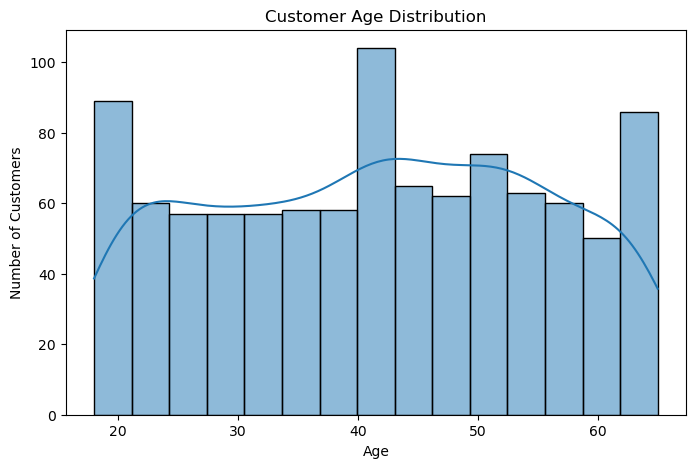

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

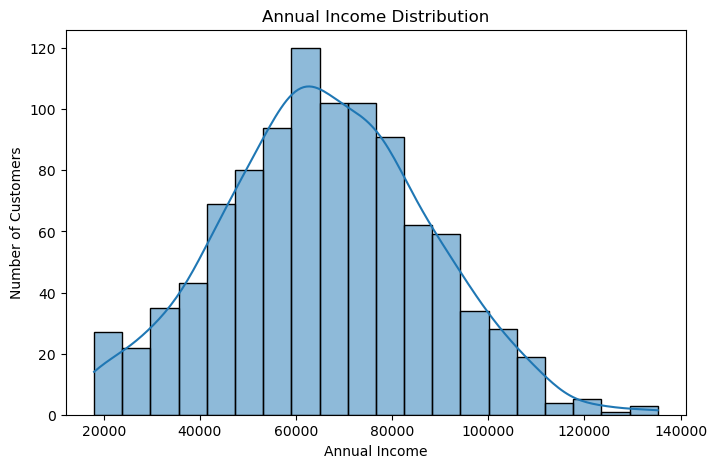

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(df["AnnualIncome"], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

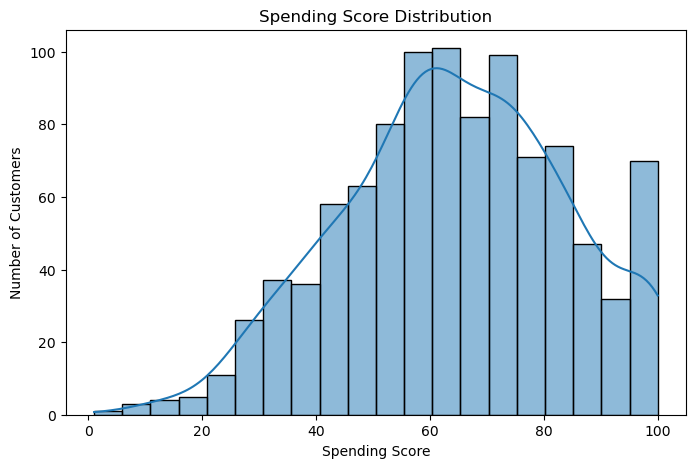

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(df["SpendingScore"], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

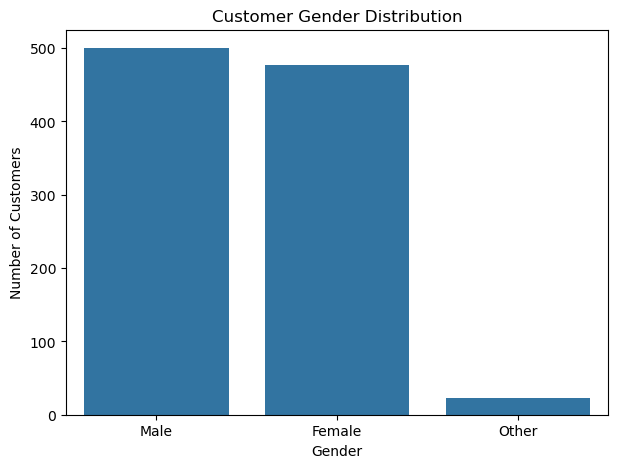

In [65]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Gender")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

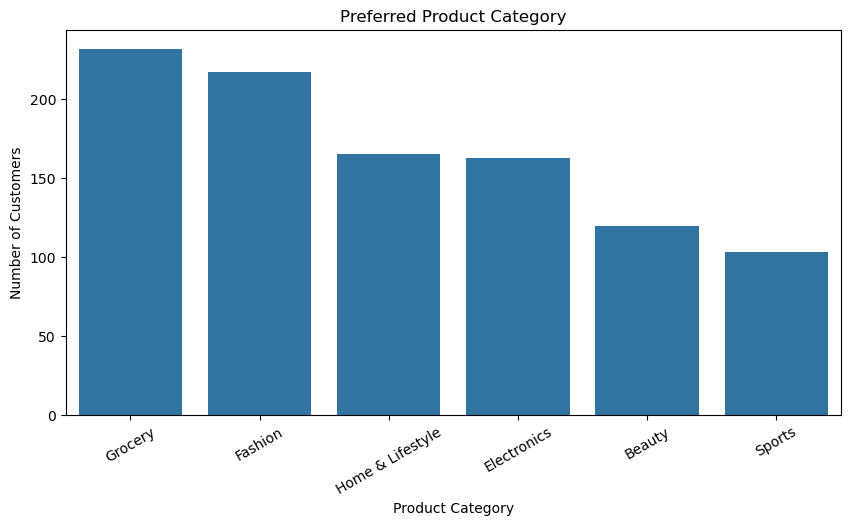

In [66]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PreferredCategory",
    order=df["PreferredCategory"].value_counts().index
)

plt.title("Preferred Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

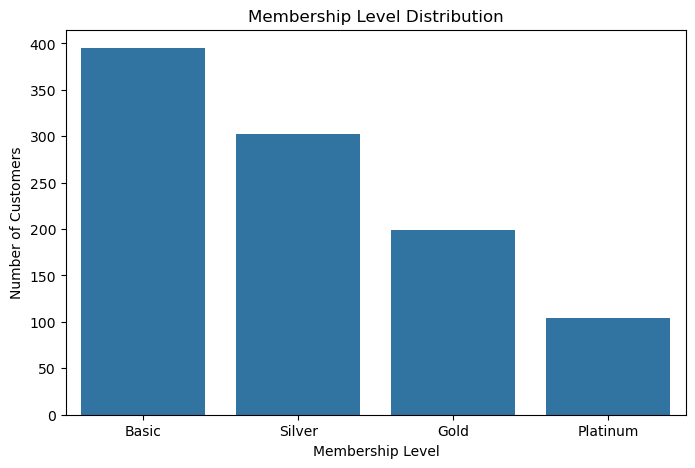

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="MembershipLevel",
    order=["Basic", "Silver", "Gold", "Platinum"]
)

plt.title("Membership Level Distribution")
plt.xlabel("Membership Level")
plt.ylabel("Number of Customers")

plt.show()

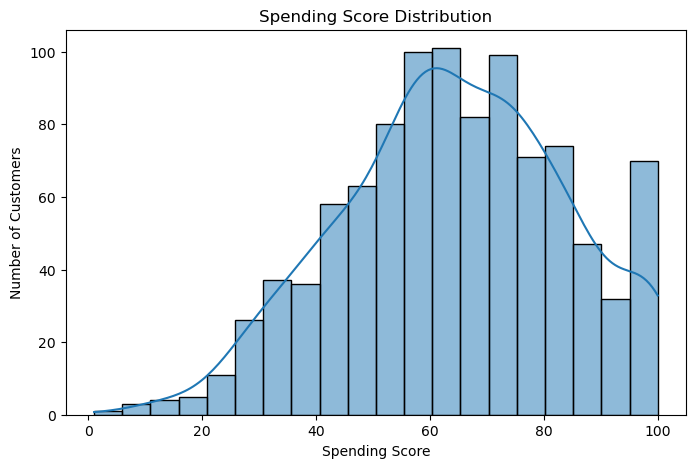

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(df["SpendingScore"], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.show()

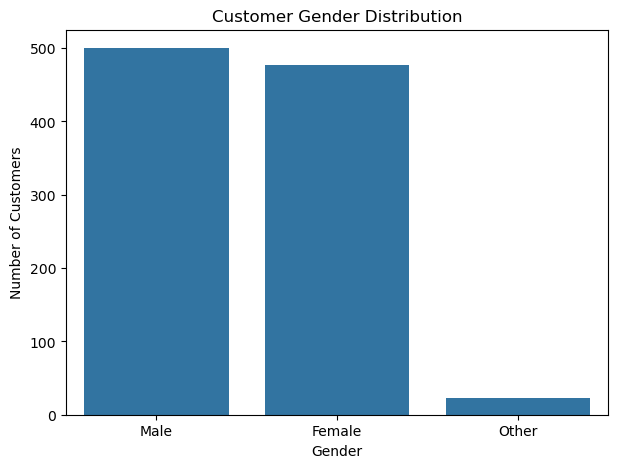

In [69]:
plt.figure(figsize=(7,5))E

sns.countplot(data=df, x="Gender")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

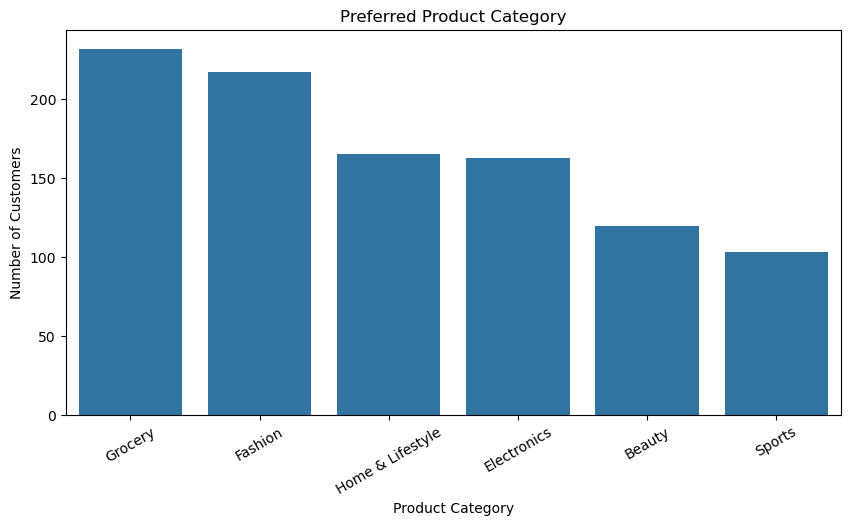

In [70]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PreferredCategory",
    order=df["PreferredCategory"].value_counts().index
)

plt.title("Preferred Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.show()

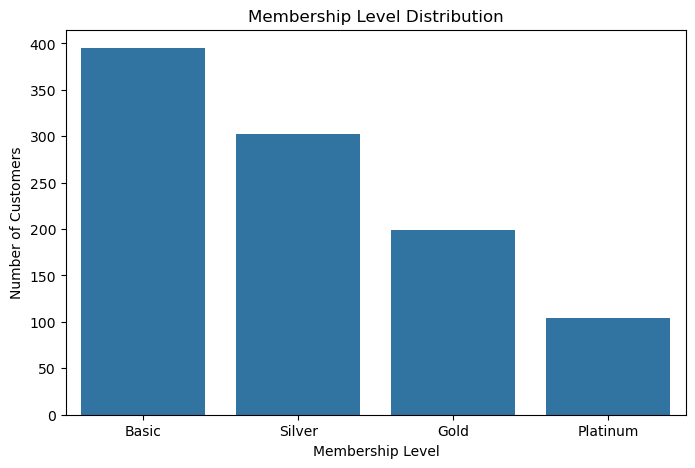

In [71]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="MembershipLevel",
    order=["Basic", "Silver", "Gold", "Platinum"]
)

plt.title("Membership Level Distribution")
plt.xlabel("Membership Level")
plt.ylabel("Number of Customers")

plt.show()

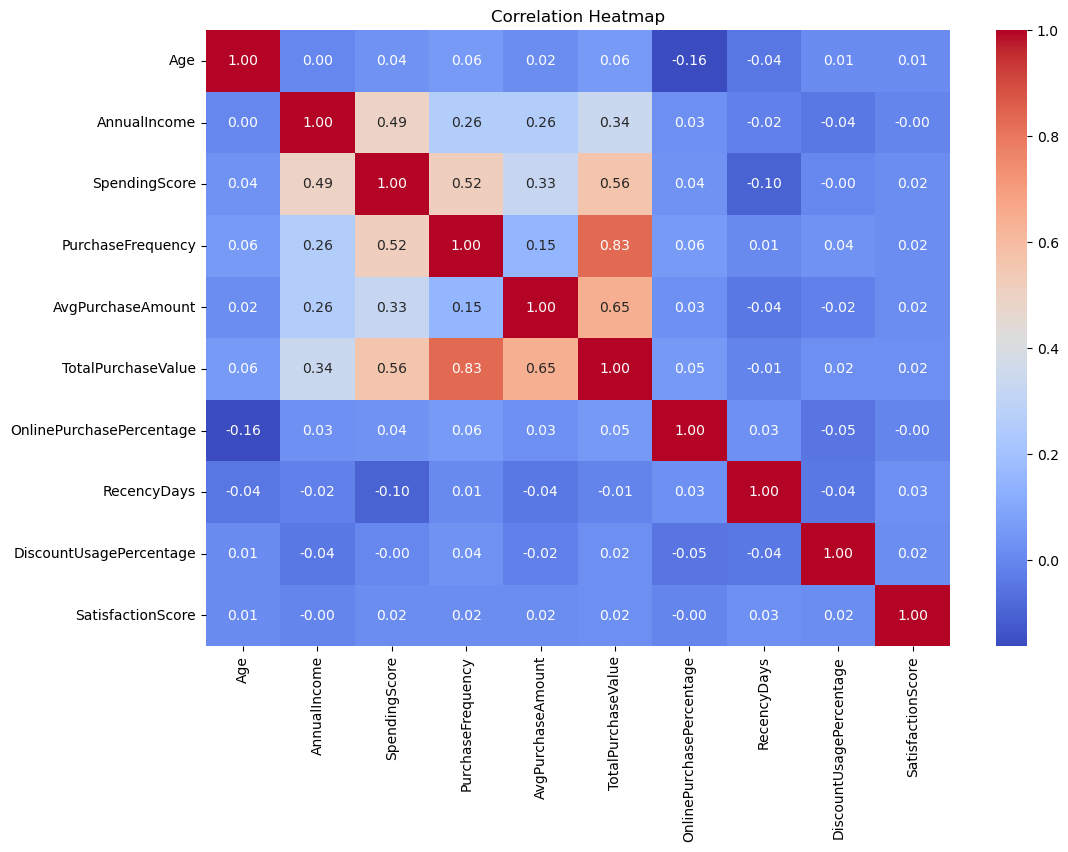

In [72]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [73]:
features = [
    "Age",
    "AnnualIncome",
    "SpendingScore",
    "PurchaseFrequency",
    "AvgPurchaseAmount",
    "TotalPurchaseValue",
    "OnlinePurchasePercentage",
    "RecencyDays",
    "DiscountUsagePercentage",
    "SatisfactionScore"
]

X = df[features]

print("Selected features:")
print(features)

print("\nShape:", X.shape)

Selected features:
['Age', 'AnnualIncome', 'SpendingScore', 'PurchaseFrequency', 'AvgPurchaseAmount', 'TotalPurchaseValue', 'OnlinePurchasePercentage', 'RecencyDays', 'DiscountUsagePercentage', 'SatisfactionScore']

Shape: (1000, 10)


In [74]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AvgPurchaseAmount,TotalPurchaseValue,OnlinePurchasePercentage,RecencyDays,DiscountUsagePercentage,SatisfactionScore
0,1.048420,-1.136519,0.241915,-1.666390,-0.854080,-1.451502,-1.838513,1.432035,-1.469431,-0.445214
1,0.321613,-0.356010,-0.719469,-0.209331,0.592348,0.107890,0.233076,-0.735919,0.153353,-0.028412
2,-0.695919,-0.668531,-0.820668,-1.666390,-0.970410,-1.477475,0.277152,-0.397176,-1.401815,-0.167346
3,1.339144,-0.234531,-1.073664,-1.666390,0.314180,-1.190671,-0.736604,-0.227804,0.829513,0.318923
4,-1.204684,0.015663,0.444311,0.762042,-0.219509,0.388417,-0.868833,1.974023,-0.455191,-0.584148


In [75]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

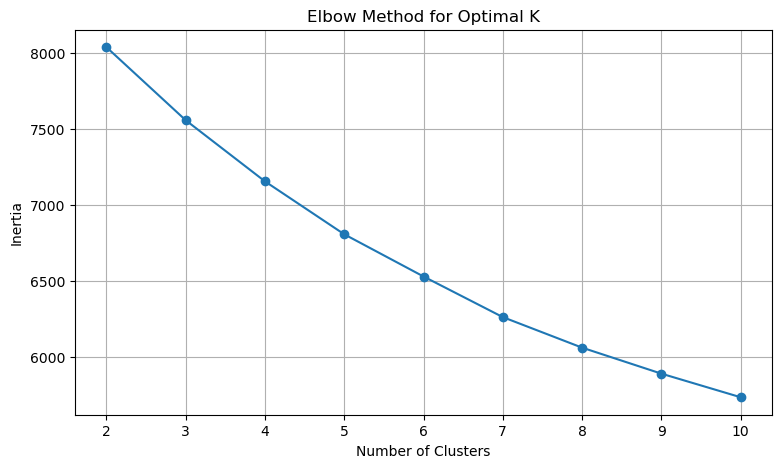

In [76]:
plt.figure(figsize=(9,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.xticks(range(2,11))
plt.grid(True)E

plt.show()

In [77]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

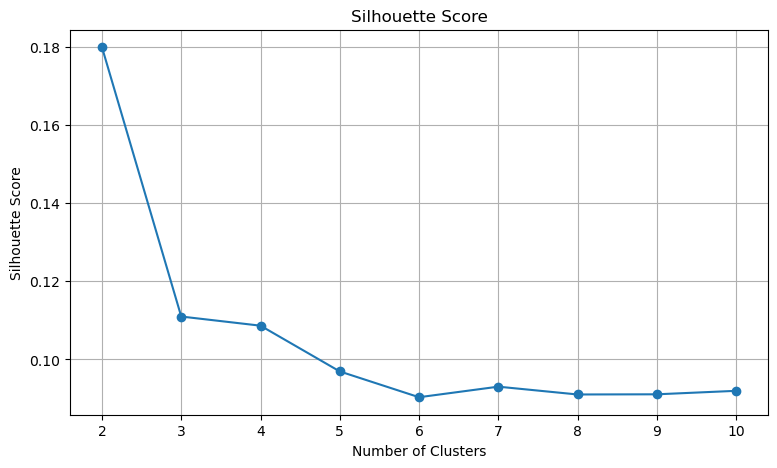

In [78]:
plt.figure(figsize=(9,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.xticks(range(2,11))
plt.grid(True)

plt.show()

In [79]:
optimal_k = 4

In [80]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")

K-Means clustering completed!


In [81]:
df["Cluster"].value_counts().sort_index()

Cluster
0    106
1    330
2    275
3    289
Name: count, dtype: int64

In [82]:
df[
    [
        "CustomerID",
        "Age",
        "AnnualIncome",
        "SpendingScore",
        "PurchaseFrequency",
        "TotalPurchaseValue",
        "Cluster"
    ]
].head(20)

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,TotalPurchaseValue,Cluster
0,CUST0001,56,41567,69,5,5107.20,3
1,CUST0002,46,58285,50,11,16364.81,2
2,CUST0003,32,51591,48,5,4919.70,2
3,CUST0004,60,60887,43,5,6990.20,3
4,CUST0005,25,66246,73,15,18390.00,0
5,CUST0006,38,76653,84,16,13170.72,0
6,CUST0007,56,63449,72,17,19673.25,1
7,CUST0008,36,75703,99,13,14551.94,1
8,CUST0009,40,66418,65,11,14513.62,2
9,CUST0010,28,21540,57,9,7069.50,3


In [83]:
cluster_profile = df.groupby("Cluster")[features].mean()

cluster_profile.round(2)

,Age,AnnualIncome,SpendingScore,PurchaseFrequency,AvgPurchaseAmount,TotalPurchaseValue,OnlinePurchasePercentage,RecencyDays,DiscountUsagePercentage,SatisfactionScore
Cluster,,,,,,,,,,
0,37.83,62432.89,58.01,11.57,1192.97,13689.12,58.45,91.44,24.20,7.57
1,43.94,78483.81,81.75,15.72,1498.11,23349.48,56.17,24.52,29.84,7.28
2,32.27,64546.76,59.70,9.71,1309.61,12518.45,68.55,20.99,25.99,7.06
3,49.11,54126.69,50.79,9.62,1092.69,10335.56,45.43,24.80,31.74,7.25


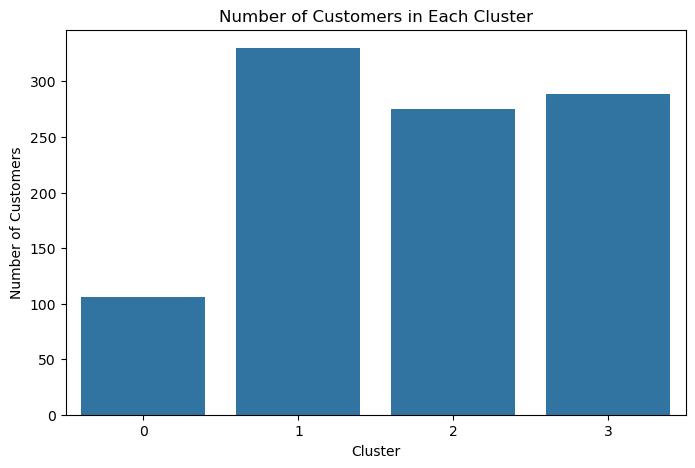

In [84]:
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [85]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

print("Explained variance:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance:
[0.28281178 0.11948138]
Total explained variance: 0.40229315382514386


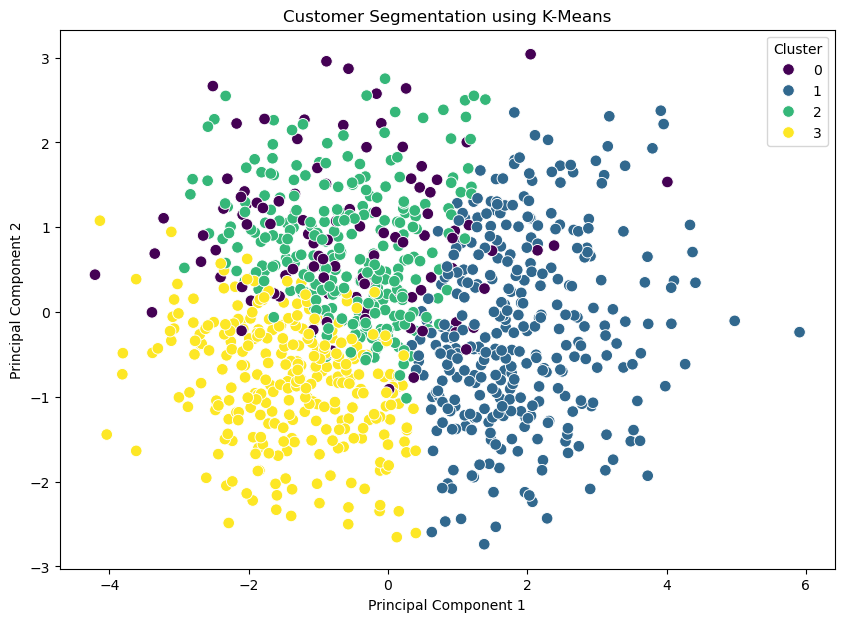

In [86]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

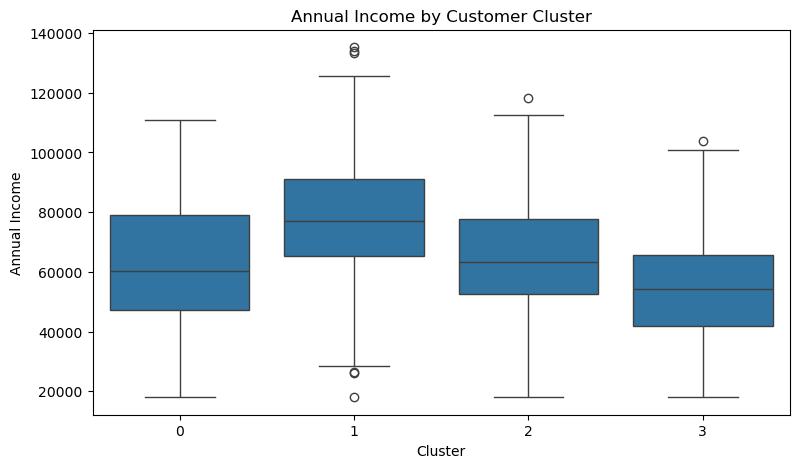

In [87]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Cluster",
    y="AnnualIncome"
)

plt.title("Annual Income by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Annual Income")

plt.show()

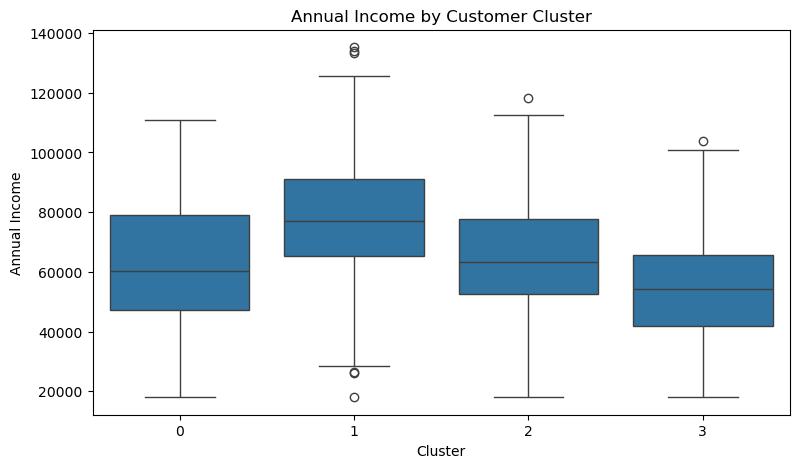

In [88]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Cluster",
    y="AnnualIncome"
)

plt.title("Annual Income by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Annual Income")

plt.show()

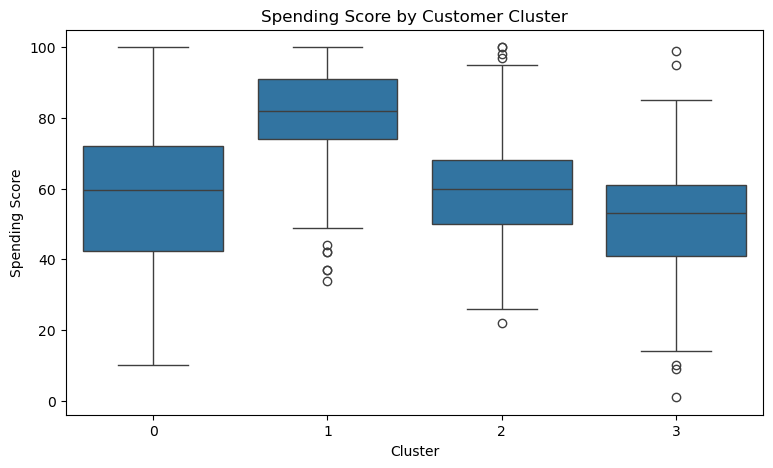

In [89]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Cluster",
    y="SpendingScore"
)

plt.title("Spending Score by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Spending Score")

plt.show()

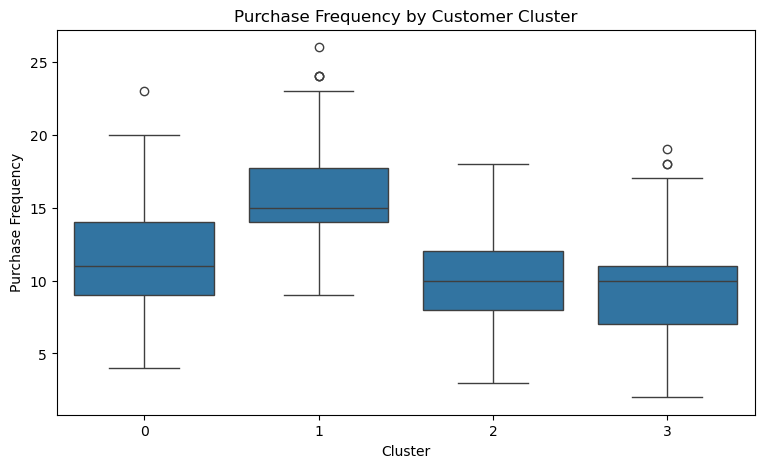

In [90]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Cluster",
    y="PurchaseFrequency"
)

plt.title("Purchase Frequency by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Purchase Frequency")

plt.show()

In [91]:
category_cluster = pd.crosstab(
    df["Cluster"],
    df["PreferredCategory"]
)

category_cluster

PreferredCategory,Beauty,Electronics,Fashion,Grocery,Home & Lifestyle,Sports
Cluster,,,,,,
0,10,21,27,25,18,5
1,42,48,70,80,61,29
2,30,46,60,59,44,36
3,38,48,60,68,42,33


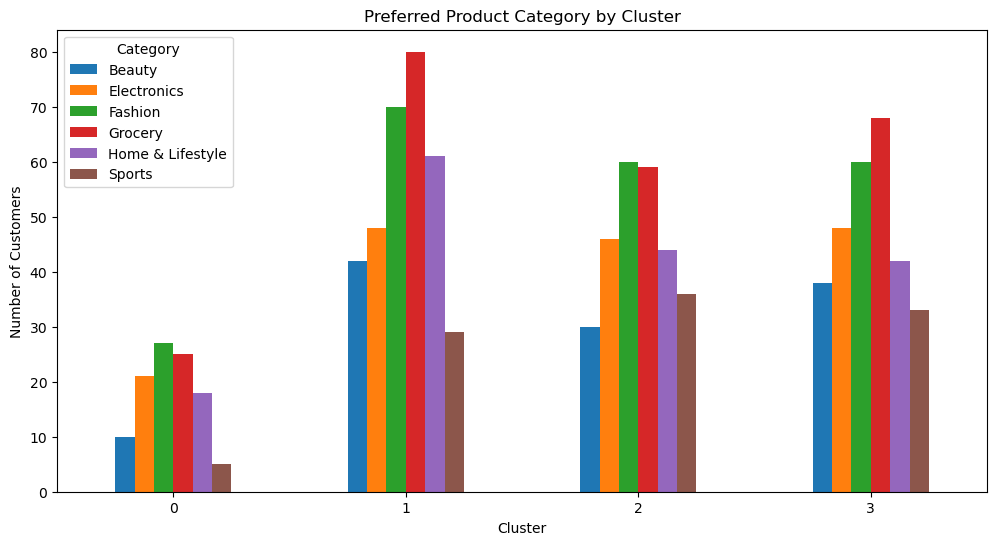

In [92]:
category_cluster.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Preferred Product Category by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.legend(title="Category")

plt.show()

In [93]:
membership_cluster = pd.crosstab(
    df["Cluster"],
    df["MembershipLevel"]
)

membership_cluster

MembershipLevel,Basic,Gold,Platinum,Silver
Cluster,,,,
0,38,20,13,35
1,132,72,28,98
2,102,58,27,88
3,123,49,36,81


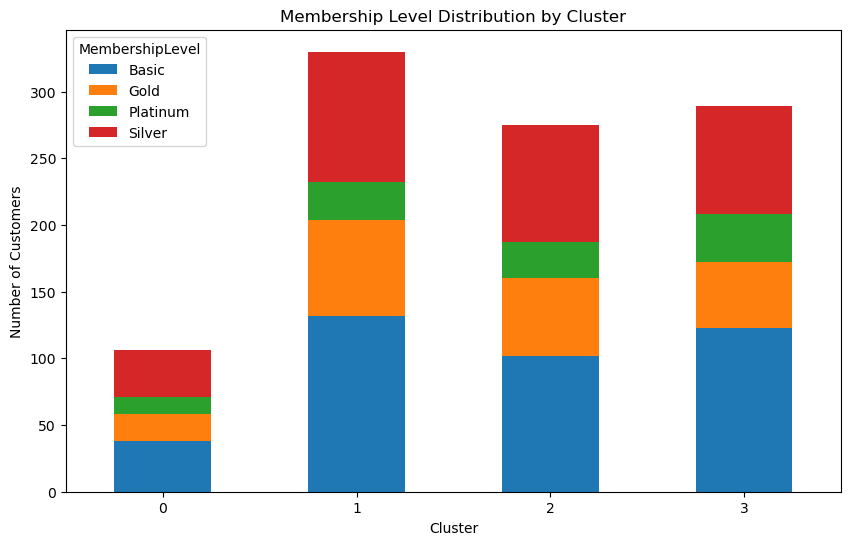

In [94]:
membership_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Membership Level Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.show()

In [95]:
summary = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("AnnualIncome", "mean"),
    Average_Spending_Score=("SpendingScore", "mean"),
    Average_Purchase_Frequency=("PurchaseFrequency", "mean"),
    Average_Purchase_Value=("TotalPurchaseValue", "mean"),
    Average_Recency=("RecencyDays", "mean"),
    Average_Satisfaction=("SatisfactionScore", "mean")
)

summary.round(2)

,Customers,Average_Age,Average_Income,Average_Spending_Score,Average_Purchase_Frequency,Average_Purchase_Value,Average_Recency,Average_Satisfaction
Cluster,,,,,,,,
0,106,37.83,62432.89,58.01,11.57,13689.12,91.44,7.57
1,330,43.94,78483.81,81.75,15.72,23349.48,24.52,7.28
2,275,32.27,64546.76,59.70,9.71,12518.45,20.99,7.06
3,289,49.11,54126.69,50.79,9.62,10335.56,24.80,7.25


In [96]:
summary.round(2)

,Customers,Average_Age,Average_Income,Average_Spending_Score,Average_Purchase_Frequency,Average_Purchase_Value,Average_Recency,Average_Satisfaction
Cluster,,,,,,,,
0,106,37.83,62432.89,58.01,11.57,13689.12,91.44,7.57
1,330,43.94,78483.81,81.75,15.72,23349.48,24.52,7.28
2,275,32.27,64546.76,59.70,9.71,12518.45,20.99,7.06
3,289,49.11,54126.69,50.79,9.62,10335.56,24.80,7.25


In [97]:
cluster_names = {
    0: "High Value Customers",
    1: "Regular Customers",
    2: "Low Engagement Customers",
    3: "Potential Customers"
}

df["CustomerSegment"] = df["Cluster"].map(cluster_names)

df[
    [
        "CustomerID",
        "Cluster",
        "CustomerSegment"
    ]
].head(20)

,CustomerID,Cluster,CustomerSegment
0,CUST0001,3,Potential Customers
1,CUST0002,2,Low Engagement Customers
2,CUST0003,2,Low Engagement Customers
3,CUST0004,3,Potential Customers
4,CUST0005,0,High Value Customers
5,CUST0006,0,High Value Customers
6,CUST0007,1,Regular Customers
7,CUST0008,1,Regular Customers
8,CUST0009,2,Low Engagement Customers
9,CUST0010,3,Potential Customers


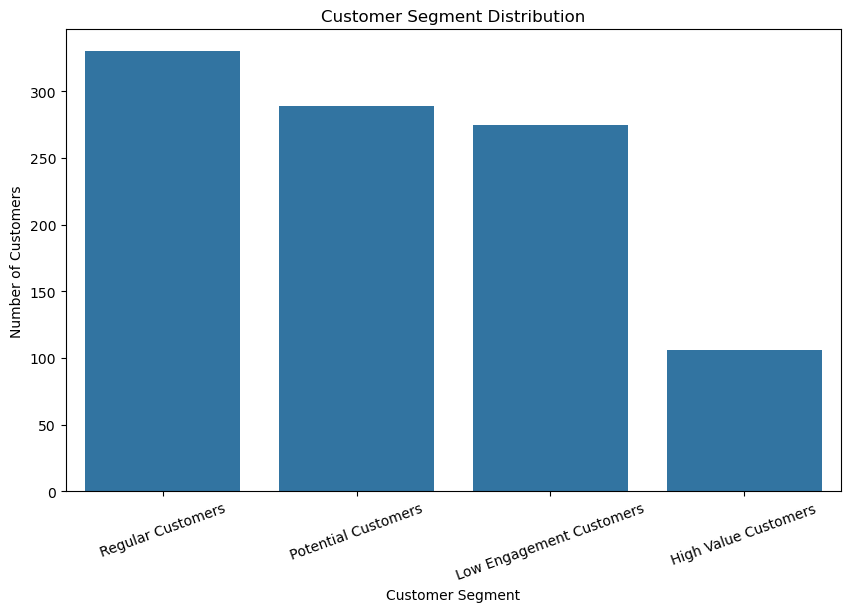

In [98]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="CustomerSegment",
    order=df["CustomerSegment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [99]:
df.to_csv(
    "customer_segmentation_with_clusters.csv",
    index=False
)

print("Final segmented dataset saved successfully!")

Final segmented dataset saved successfully!
